# Training for Old Data (engine_1)

In [2]:
import numpy as np
import os
import pandas as pd
import glob
import random
import yaml
import seaborn as sns

from src.electrical_signature_frequencies import ANOMALY_FREQS
from src.anomaly_injector import GaussianPeakInjector, NoiseInjector, CompositeAnomalyInjector
import matplotlib.pyplot as plt

import torch

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Set device 
device: str = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
# experiment.log_parameter("device", device)
device = torch.device(device)
print("Using device:", device)

Using device: mps


## Configuration

In [3]:
base_dir = "../dataset/engine_1"

# Load Engine Configuration
path2engine_cfg = os.path.join(base_dir, 'engine.yml')
with open(path2engine_cfg, 'r') as f:
    engine_config = yaml.safe_load(f)


In [4]:
# Load Dataset Metadata
metadata_df = pd.read_csv(os.path.join(base_dir, 'metadata.csv'))

In [5]:
metadata_df

,measurement_id,base_id,experiment,state,load_condition,phase,num_observations,file_path,engine_cfg_path
0,7022023102148_1,7022023102148,experiment_3,normal,NaN,1,10000,../dataset/engine_1/experiment_3/0702 без пере...,../dataset/engine_1/engine.yml
1,7022023111156_1,7022023111156,experiment_3,inter-turn short circuits,NaN,1,50000,../dataset/engine_1/experiment_3/0702 межвитк...,../dataset/engine_1/engine.yml
2,20012023124936_1,20012023124936,experiment_2,rotor bar defect,NaN,1,100000,../dataset/engine_1/experiment_2/20_01_1460_об...,../dataset/engine_1/engine.yml


In [7]:
# Load training and processing parameters
with open("../training_configs/train-engine-1.yml", "r") as f:
    train_params = yaml.safe_load(f)

# Processing Parameters
f_sampling = train_params["processing_parameters"]["f_sampling"]
shift = train_params["processing_parameters"]["shift"]
segment_length = train_params["processing_parameters"]["segment_length"]
cutoff_freq = train_params["processing_parameters"]["cutoff_freq"]
peak_type = train_params["processing_parameters"]["peak_type"]
peak_segment = train_params["processing_parameters"]["peak_segment"]
amplitude_range = tuple(train_params["processing_parameters"]["amplitude_range"])
sigma_range = tuple(train_params["processing_parameters"]["sigma_range"])
noise_factor = train_params["processing_parameters"]["noise_factor"]

# Training Parameters
num_epochs_binary = train_params["training_parameters"]["num_epochs_binary"]
num_epochs_multi = train_params["training_parameters"]["num_epochs_multi"]

# Data Parameters
batch_size = train_params["data_parameters"]["batch_size"]

# Dataset Parameters
normalization_method = train_params["dataset_parameters"]["normalization_method"]

In [8]:
MCSA_cfg = {
    'rotor bar defect': {
        'engine_config': engine_config['mcsa'],
        'n_range': range(1, 4)
        },
    'inter-turn short circuits': {
        'engine_config': engine_config['mcsa'],
        'k_range': range(1, 4, 2), 
        'm_range': range(0, 2)
        },
    'bearing defect': {
        'engine_config': engine_config['mcsa']
        },
}

fault_types_available = [state for state in metadata_df['state'].unique() if state != 'normal']

fault_freqs = {
    fault_type: ANOMALY_FREQS[fault_type](**MCSA_cfg[fault_type]) for fault_type in fault_types_available
}

In [10]:
# Instantiate the Gaussian injector
gaussian_injector = GaussianPeakInjector(
    peak_segment=peak_segment,
    amplitude_range=amplitude_range,
    sigma_range=sigma_range
)

# Instantiate the Noise injector
noise_injector = NoiseInjector(noise_factor=noise_factor)

# Combine the injectors
composite_injector = CompositeAnomalyInjector({
    'peak-anomaly': gaussian_injector,
    'noise': noise_injector
})

## Load Data

In [18]:
from tqdm.auto import tqdm

from src.data_pipeline import (
    segment_signal,
    perform_fft_on_segments,
    normalize_segment,
    load_measurement,
    read_oscilloscope_data
)

import os
import random
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, TensorDataset

In [19]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ 1.  PRE-PROCESSING                                                      ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def preprocessing(
    metadata_df: pd.DataFrame,
    out_dir: str,
    segment_length: int,
    step: int,
    f_sampling: int,
    cutoff_freq: int,
    apply_window: bool = False,
    db: bool = True,
) -> Tuple[np.ndarray, pd.DataFrame, np.ndarray]:
    """
    Convert every measurement in *metadata_df* into FFT magnitude windows.

    Parameters
    ----------
    metadata_df : pd.DataFrame
        Measurement-level table produced by `create_metadata_df`.  **Must** be
        indexed by `"measurement_id"` and contain at least the columns:

            ["state", "phase", "load_condition", "experiment"]

    out_dir : str
        Destination directory for the three artefacts written to disk.

    segment_length : int
        Number of time-domain samples per window.

    step : int
        Hop-size (in samples) between consecutive windows.

    f_sampling : int
        Sampling frequency (Hz) used to compute the frequency vector.

    cutoff_freq : int
        Keep FFT bins only up to this frequency (Hz).

    apply_window : bool, optional
        If *True*, applies a Hann window to every slice before the FFT.
        Default = *False* (good enough for equally spaced integer cycles).

    db : bool, optional
        If *True*, returns magnitude in decibels.  Default = *True*.

    Returns
    -------
    segments : np.ndarray
        Dense float32 array of shape *(N_segments, segment_length)* holding the
        pre-processed FFT spectra.

    seg_meta_df : pd.DataFrame
        Segment-level metadata indexed by the **compound** key
        ``["measurement_id", "segment_idx"]`` - row order is **identical** to
        *segments*.

    freqs : np.ndarray
        1-D float64 array (length = *segment_length*) with the frequency bins
        (post cut-off).

    Notes
    -----
    * The function deliberately **does not** sort the DataFrame, preserving the
      original row order so that `segments[i]` <—> `seg_meta_df.iloc[i]`.
    """
    seg_rows: List[dict] = []
    seg_arrays: List[np.ndarray] = []
    freqs: Optional[np.ndarray] = None

    for m_id, meta in tqdm(metadata_df.iterrows(),
                           total=len(metadata_df),
                           desc="pre-processing"):
        # 1) Load the CSV
        # df = load_measurement(m_id, metadata_df)
        # current = df["Current"].dropna().values

        # 1) Load the TXT
        df = read_oscilloscope_data(meta['file_path'])
        current = df["Data"].dropna().values

        # 2) Time-domain slicing
        win_arr = segment_signal(
            current,
            segment_length=segment_length,
            step=step,
            apply_window=apply_window,
        )

        # 3) FFT magnitude spectra
        fft_arr, freqs = perform_fft_on_segments(
            win_arr,
            f_sampling=f_sampling,
            cutoff_freq=cutoff_freq,
            db=db,
        )

        # 4) Build a metadata row for every segment
        n_segments = fft_arr.shape[0]
        for s_idx in range(n_segments):
            start_t = df.index[s_idx * step]
            end_t   = df.index[s_idx * step + segment_length - 1]
            seg_rows.append({
                "measurement_id":  m_id,
                "segment_idx":     s_idx,
                "start_time":      float(start_t),
                "end_time":        float(end_t),
                "state":           meta["state"],
                "binary_label":    0 if meta["state"] == "normal" else 1,
                "multiclass_label": meta["state"],
                "phase":           int(meta["phase"]),
                "load_condition":  meta["load_condition"],
                "experiment":      meta["experiment"],
            })
        seg_arrays.append(fft_arr.astype(np.float32))

    # 5) Concatenate and persist
    segments = np.vstack(seg_arrays)                              # shape = (N, L)
    seg_meta_df = pd.DataFrame(seg_rows).set_index(
        ["measurement_id", "segment_idx"]
    )

    os.makedirs(out_dir, exist_ok=True)
    np.save(os.path.join(out_dir, "segments.npy"), segments)
    np.save(os.path.join(out_dir, "freqs.npy"), freqs)
    seg_meta_df.to_csv(os.path.join(out_dir, "segments_metadata.csv"))

    return segments, seg_meta_df, freqs

In [20]:
segments, seg_meta_df, freqs = preprocessing(
    metadata_df      = metadata_df,
    out_dir          = base_dir,
    segment_length   = segment_length,
    step             = shift,
    f_sampling       = f_sampling,
    cutoff_freq      = cutoff_freq,
    apply_window     = False,
    db               = True
)

pre-processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [21]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ 2.  DATASET WITH ON-THE-FLY FAULT INJECTION                             ║
# ╚══════════════════════════════════════════════════════════════════════════╝
class DynamicDataset(Dataset):
    """
    A PyTorch `Dataset` that *dynamically* balances the classes by injecting
    synthetic fault signatures into **normal** FFT windows with a user-defined
    probability *p_inject*.

    Behaviour
    ---------
    • If the original *state* == "normal"
        - With probability *p_inject* : replace window with a *synthetic* fault
        - With probability 1-*p_inject* : leave it normal
    • If the original *state* ≠ "normal"
        - Return window unchanged (authentic fault)

    Optional noise injection is performed **after** any synthetic fault
    generation so that SNR matches reality.

    Parameters
    ----------
    segments : np.ndarray
        FFT windows (N, L) - memory-mapped arrays work fine.

    seg_meta_df : pd.DataFrame
        Must be row-aligned with *segments* (see `preprocessing`).

    freqs : np.ndarray
        Frequency vector (L,).

    fault_freqs : Dict[str, np.ndarray]
        Mapping *fault_type* → array of characteristic fault frequencies
        (centre frequencies for Gaussian peaks).

    mode : {'binary', 'multiclass'}, default='binary'
        Governs target labels:
            binary     : 0 = normal, 1 = any fault
            multiclass : encoded with `LabelEncoder`

    normalization_method : {'min-max', 'z-score', None}, optional
        On-the-fly normalisation.  If *None*, raw dB magnitudes are returned.

    anomaly_injector : CompositeAnomalyInjector, optional
        Instance capable of injecting Gaussian peaks and/or additive noise.
        Must expose `.inject(segment, fft_freqs, fault_freqs, injector_keys)`.

    fault_injection_prob : float, default=0.5
        Probability *p* that a normal window is converted into a synthetic
        fault.

    label_encoder : LabelEncoder, optional
        Pre-fit encoder for multiclass mode.  If *None*, a new encoder is fit
        on *fault_freqs.keys() ∪ {'normal'}*.

    Returns
    -------
    Tuple[torch.Tensor, int]
        *Input*  : tensor with shape (1, L)
        *Target* : integer label (see *mode*)
    """

    def __init__(
        self,
        segments: np.ndarray,
        seg_meta_df: pd.DataFrame,
        freqs: np.ndarray,
        fault_freqs: Dict[str, np.ndarray],
        mode: str = "binary",
        normalization_method: Optional[str] = "min-max",
        anomaly_injector: Optional[Any] = None,
        fault_injection_prob: float = 0.5,
        label_encoder: Optional[LabelEncoder] = None,
    ) -> None:
        super().__init__()
        assert 0.0 <= fault_injection_prob <= 1.0, "probability must be in [0,1]"
        self.segments = segments
        self.seg_meta_df = seg_meta_df
        self.freqs = freqs
        self.anomaly_injector = anomaly_injector
        self.mode = mode
        self.norm_method = normalization_method
        self.p_inject = float(fault_injection_prob)

        # fault taxonomy
        self.fault_freqs = fault_freqs
        self.fault_types = sorted(list(fault_freqs.keys()))

        # encoder for multiclass
        if mode == "multiclass":
            if label_encoder is None:
                label_encoder = LabelEncoder().fit(self.fault_types + ["normal"])
            self.le = label_encoder
        else:
            self.le = None

    def __len__(self) -> int:
        return len(self.segments)

    def _choose_label_for_normal(self) -> str:
        """Randomly decide whether a normal window becomes a fault."""
        if np.random.rand() < self.p_inject:
            return np.random.choice(self.fault_types)
        return "normal"

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        seg = self.segments[idx].copy()          # (L,)
        meta = self.seg_meta_df.iloc[idx]
        orig_label = meta["state"]

        # ── 1. maybe inject fault if originally normal ─────────────────
        if orig_label == "normal":
            chosen_label = self._choose_label_for_normal()
            if chosen_label != "normal" and self.anomaly_injector is not None:
                seg = self.anomaly_injector.inject(
                    segment       = seg,
                    fft_freqs     = self.freqs,
                    fault_freqs   = self.fault_freqs[chosen_label],
                    injector_keys = ["peak-anomaly"],
                )
        else:
            chosen_label = orig_label  # keep authentic fault

        # ── 2. optional noise injection ────────────────────────────────
        if self.anomaly_injector is not None and "noise" in self.anomaly_injector.injectors:
            seg = self.anomaly_injector.inject(
                segment       = seg,
                fft_freqs     = self.freqs,
                fault_freqs   = None,
                injector_keys = ["noise"],
            )

        # ── 3. optional normalisation  ─────────────────────────────────
        if self.norm_method:
            seg, _ = normalize_segment(seg, self.norm_method)

        # ── 4. pack → torch.Tensor + encode label ──────────────────────
        seg_tensor = torch.tensor(seg, dtype=torch.float32).unsqueeze(0)  # (1, L)

        if self.mode == "binary":
            y = 0 if chosen_label == "normal" else 1
        else:  # multiclass
            y = int(self.le.transform([chosen_label])[0])

        return seg_tensor, y

In [22]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ 3.  TRAIN / VAL / TEST  BALANCED SPLITTER                               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def _min_per_class(group: Dict[str, np.ndarray]) -> int:
    """Return the size of the smallest class (for perfect undersampling)."""
    return min(len(v) for v in group.values())


def create_balanced_datasets(
    segments: np.ndarray,
    seg_meta_df: pd.DataFrame,
    freqs: np.ndarray,
    fault_freqs: Dict[str, np.ndarray],
    mode: str = "binary",
    normalization_method: str = "min-max",
    test_size: float = 0.30,
    val_size: float = 0.20,
    seed: int = 42,
    anomaly_injector: Optional[Any] = None,
    real_fault_train: int = 0,
) -> Dict[str, Any]:
    """
    Produce three datasets (*train*, *val*, *test*) that are class-balanced.

    Strategy
    --------
    • **Training set** -
        * All normal windows from the training split.
        * *real_fault_train* authentic fault windows (undersampled if necessary).
        * `fault_injection_prob` is auto-computed so that the *expected* number
          of injected faults brings the class counts into equilibrium.

    • **Validation / Test sets** -
        * Perfectly balanced via undersampling: each class contributes the same
          number of windows (= size of the smallest class).

    Parameters
    ----------
    segments, seg_meta_df, freqs : artefacts from `preprocessing`.

    fault_freqs : dict
        Keys = fault type strings, values = frequency arrays used by the
        `DynamicDataset` when injecting synthetic peaks.

    mode : {'binary', 'multiclass'}

    normalization_method : str, optional
        On-the-fly normalisation method for *train* and immediate normalisation
        for *val* / *test*.

    test_size : float
        Fraction of **normal** windows reserved for the *test* split.

    val_size : float
        Fraction of **normal** windows reserved for *validation* *after* the
        test split is carved out.

    real_fault_train : int
        Exact number of authentic fault windows you wish to keep for training
        (if available).  Set to 0 for fully synthetic training faults.

    Returns
    -------
    Dict[str, Any]
        ``{"train": DynamicDataset, "val": TensorDataset, "test": TensorDataset,
           "label_encoder": <LabelEncoder> (multiclass only)}``
    """
    rng = np.random.default_rng(seed)

    # ── 1. Separate indices by label ───────────────────────────────────
    normal_idx = seg_meta_df.index[seg_meta_df["state"] == "normal"].to_numpy()
    fault_idx_all = seg_meta_df.index[seg_meta_df["state"] != "normal"].to_numpy()

    # ── 2. Choose authentic fault windows for training ────────────────
    real_fault_train = int(real_fault_train)
    real_fault_train = min(real_fault_train, len(fault_idx_all))
    train_fault_idx = rng.choice(fault_idx_all, real_fault_train, replace=False)
    fault_idx_eval = np.setdiff1d(fault_idx_all, train_fault_idx)

    # ── 3. Split normals: train / val / test ───────────────────────────
    norm_train_idx, norm_test_idx = train_test_split(
        normal_idx, test_size=test_size, random_state=seed, shuffle=True
    )
    norm_train_idx, norm_val_idx = train_test_split(
        norm_train_idx,
        test_size=val_size / (1.0 - test_size),
        random_state=seed,
        shuffle=True,
    )

    # ── 4. Split evaluation faults: val / test ────────────────────────
    fault_val_idx, fault_test_idx = train_test_split(
        fault_idx_eval,
        test_size=test_size / (val_size + test_size),
        random_state=seed,
        shuffle=True,
    )

    # ── 5. Balance VAL / TEST via undersampling ────────────────────────
    if mode == "binary":
        by_cls_val = {"normal": norm_val_idx, "fault": fault_val_idx}
        by_cls_test = {"normal": norm_test_idx, "fault": fault_test_idx}
        n_val  = _min_per_class(by_cls_val)
        n_test = _min_per_class(by_cls_test)
        val_idx  = np.concatenate([
            rng.choice(by_cls_val["normal"], n_val,  replace=False),
            rng.choice(by_cls_val["fault"],  n_val,  replace=False),
        ])
        test_idx = np.concatenate([
            rng.choice(by_cls_test["normal"], n_test, replace=False),
            rng.choice(by_cls_test["fault"],  n_test, replace=False),
        ])
    else:  # multiclass
        classes = seg_meta_df["state"].unique().tolist()
        by_cls_val  = {c: seg_meta_df.index[
            (seg_meta_df["state"] == c) &
            (seg_meta_df.index.isin(norm_val_idx) |
             seg_meta_df.index.isin(fault_val_idx))
        ].to_numpy() for c in classes}
        by_cls_test = {c: seg_meta_df.index[
            (seg_meta_df["state"] == c) &
            (seg_meta_df.index.isin(norm_test_idx) |
             seg_meta_df.index.isin(fault_test_idx))
        ].to_numpy() for c in classes}
        n_val  = _min_per_class(by_cls_val)
        n_test = _min_per_class(by_cls_test)
        val_idx  = np.concatenate([
            rng.choice(by_cls_val[c],  n_val,  replace=False) for c in classes
        ])
        test_idx = np.concatenate([
            rng.choice(by_cls_test[c], n_test, replace=False) for c in classes
        ])

    # ── 6. Assemble TRAIN indices ──────────────────────────────────────
    train_idx = np.concatenate([norm_train_idx, train_fault_idx])

    # ── 7. Build NumPy views for each split ────────────────────────────
    idx2row = seg_meta_df.index.get_indexer  # vectorised (fast)
    X_train = segments[idx2row(train_idx)]
    X_val   = segments[idx2row(val_idx)]
    X_test  = segments[idx2row(test_idx)]

    # immediate normalisation for val/test
    if normalization_method:
        X_val  = np.stack([normalize_segment(s, normalization_method)[0] for s in X_val])
        X_test = np.stack([normalize_segment(s, normalization_method)[0] for s in X_test])

    # ── 8. Prepare labels for evaluation sets ──────────────────────────
    y_val_raw  = seg_meta_df.loc[val_idx,  "state"].values
    y_test_raw = seg_meta_df.loc[test_idx, "state"].values

    if mode == "binary":
        y_val  = np.where(y_val_raw  == "normal", 0, 1).astype(np.int64)
        y_test = np.where(y_test_raw == "normal", 0, 1).astype(np.int64)
        label_encoder = None
    else:
        label_encoder = LabelEncoder().fit(seg_meta_df["state"])
        y_val  = label_encoder.transform(y_val_raw).astype(np.int64)
        y_test = label_encoder.transform(y_test_raw).astype(np.int64)

    # ── 9. Auto-tune p_inject to reach balance in TRAIN ────────────────
    N_norm_train = len(norm_train_idx)
    if mode == "binary":
        p_inject = max(0.0, min(1.0, 0.5 - real_fault_train / (2.0 * N_norm_train)))
    else:
        k = len(fault_freqs)           # #fault classes
        p_inject = max(0.0, min(1.0, 1.0 / (k + 1)))

    if p_inject == 0.0 and real_fault_train > 0:
        print(f"[WARN] real_fault_train={real_fault_train} exceeds balancing "
              "capacity - train set will be fault-heavy.")

    # ── 10. Construct datasets ─────────────────────────────────────────
    train_dataset = DynamicDataset(
        segments            = X_train,
        seg_meta_df         = seg_meta_df.loc[train_idx],
        freqs               = freqs,
        fault_freqs         = fault_freqs,
        mode                = mode,
        normalization_method= normalization_method,
        anomaly_injector    = anomaly_injector,
        fault_injection_prob= p_inject,
        label_encoder       = label_encoder,
    )

    val_dataset = TensorDataset(
        torch.tensor(X_val,  dtype=torch.float32).unsqueeze(1),
        torch.tensor(y_val,  dtype=torch.long),
    )
    test_dataset = TensorDataset(
        torch.tensor(X_test, dtype=torch.float32).unsqueeze(1),
        torch.tensor(y_test, dtype=torch.long),
    )

    out: Dict[str, Any] = {
        "train": train_dataset,
        "val":   val_dataset,
        "test":  test_dataset,
    }
    if mode == "multiclass":
        out["label_encoder"] = label_encoder
    return out

### Binary Dataset

In [24]:
datasets_binary = create_balanced_datasets(
    segments          = segments,
    seg_meta_df       = seg_meta_df,
    freqs             = freqs,
    fault_freqs       = fault_freqs,
    mode              = "binary",
    test_size         = 0.50,
    val_size          = 0.10,
    real_fault_train  = 0,
    anomaly_injector  = composite_injector
)

In [25]:
from torch.utils.data import DataLoader

# Loaders
train_loader_binary = DataLoader(datasets_binary["train"], batch_size=batch_size, shuffle=True)
val_loader_binary   = DataLoader(datasets_binary["val"], batch_size=batch_size, shuffle=False)
test_loader_binary  = DataLoader(datasets_binary["test"], batch_size=batch_size, shuffle=False)

### Multiclass Dataset

In [27]:
datasets_multi = create_balanced_datasets(
    segments          = segments,
    seg_meta_df       = seg_meta_df,
    freqs             = freqs,
    fault_freqs       = fault_freqs,
    mode              = "multiclass",
    test_size         = 0.50,
    val_size          = 0.10,
    real_fault_train  = 0,
    anomaly_injector  = composite_injector
)

In [28]:
# Loaders
train_loader_multi = DataLoader(datasets_multi["train"], batch_size=batch_size, shuffle=True)
val_loader_multi = DataLoader(datasets_multi["val"], batch_size=batch_size, shuffle=False)
test_loader_multi = DataLoader(datasets_multi["test"], batch_size=batch_size, shuffle=False)

## Training

### Binary Classification

In [30]:
from src.models import ResNet, ResidualBlock
from src.train import train_model
from src.inference import inference_resnet_model
from src.evaluation import calculate_metrics
from sklearn.metrics import classification_report

In [31]:
# Initialize ResNet
model_bin = ResNet(ResidualBlock, [2, 2, 2, 2], num_classes=2, block_kwargs={'use_se': False}).to(device)
print("Training ResNet for binary classification...")
model_bin = train_model(model_bin, train_loader_binary, val_loader=val_loader_binary, device=device, num_epochs=num_epochs_binary)

Training ResNet for binary classification...


Epoch 1/10:   0%|          | 0/113 [00:00<?, ?batch/s]

Epoch [1/10], Loss: 0.5362
Validation Loss: 0.9478, Accuracy: 67.00%
Best model updated.


Epoch 2/10:   0%|          | 0/113 [00:00<?, ?batch/s]

Epoch [2/10], Loss: 0.1823
Validation Loss: 0.5099, Accuracy: 91.00%
Best model updated.


...

Epoch [8/10], Loss: 0.0162
Validation Loss: 0.3751, Accuracy: 90.22%


Epoch 9/10:   0%|          | 0/113 [00:00<?, ?batch/s]

Epoch [9/10], Loss: 0.0219
Validation Loss: 0.3918, Accuracy: 89.78%


Epoch 10/10:   0%|          | 0/113 [00:00<?, ?batch/s]

Epoch [10/10], Loss: 0.0179
Validation Loss: 0.2996, Accuracy: 92.33%
Best model updated.


In [32]:
true_labels_bin, predictions_bin = inference_resnet_model(model_bin, test_loader_binary, device=device)

Inference:   0%|          | 0/282 [00:00<?, ?batch/s]

In [33]:
# Calculate metrics 
cm_bin, acc_bin, prec_bin, rec_bin, f1_bin = calculate_metrics(true_labels_bin, predictions_bin)

In [34]:
binary_report = classification_report(true_labels_bin, predictions_bin, target_names=['normal', 'anomalous'])
# binary_report_prefixed = {f"binary_{key}": value for key, value in binary_report.items()}
print(binary_report)

              precision    recall  f1-score   support

      normal       0.85      1.00      0.92      2251
   anomalous       1.00      0.83      0.91      2251

    accuracy                           0.91      4502
   macro avg       0.93      0.91      0.91      4502
weighted avg       0.93      0.91      0.91      4502



Text(0.5, 1.0, 'Binary Classification - Confusion Matrix')

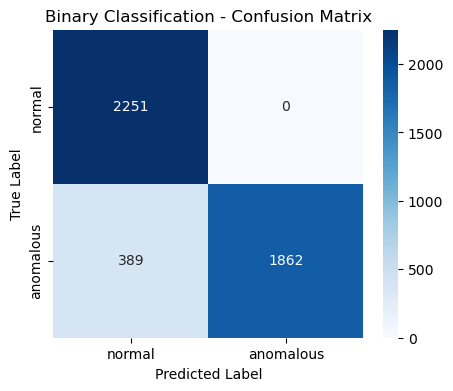

In [35]:
fig_bin, ax_bin = plt.subplots(figsize=(5,4))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues',
            xticklabels=['normal','anomalous'], yticklabels=['normal','anomalous'], ax=ax_bin)
ax_bin.set_xlabel('Predicted Label')
ax_bin.set_ylabel('True Label')
ax_bin.set_title('Binary Classification - Confusion Matrix')

### Multiclass Classification

In [36]:
# Train ResNet for Multiclass Classification
num_classes_multi = len(datasets_multi['label_encoder'].classes_)
model_multi = ResNet(ResidualBlock, [2, 2, 2, 2], num_classes=num_classes_multi, block_kwargs={'use_se': False}).to(device)
print("Training ResNet for multiclass classification...")
model_multi = train_model(model_multi, train_loader_multi, val_loader=val_loader_multi, device=device, num_epochs=num_epochs_multi)

Training ResNet for multiclass classification...


Epoch 1/10:   0%|          | 0/113 [00:00<?, ?batch/s]

Epoch [1/10], Loss: 0.7077
Validation Loss: 2.3240, Accuracy: 41.19%
Best model updated.


Epoch 2/10:   0%|          | 0/113 [00:00<?, ?batch/s]

Epoch [2/10], Loss: 0.1979
Validation Loss: 2.0751, Accuracy: 52.55%
Best model updated.


...

Epoch [8/10], Loss: 0.0236
Validation Loss: 2.1165, Accuracy: 61.46%


Epoch 9/10:   0%|          | 0/113 [00:00<?, ?batch/s]

Epoch [9/10], Loss: 0.0157
Validation Loss: 1.4007, Accuracy: 66.35%
Best model updated.


Epoch 10/10:   0%|          | 0/113 [00:00<?, ?batch/s]

Epoch [10/10], Loss: 0.0099
Validation Loss: 1.3649, Accuracy: 67.73%
Best model updated.


In [37]:
true_labels_multi, predictions_multi = inference_resnet_model(model_multi, test_loader_multi, device=device)

Inference:   0%|          | 0/317 [00:00<?, ?batch/s]

In [38]:
# Calculate metrics 
cm_multi, acc_multi, prec_multi, rec_multi, f1_multi = calculate_metrics(true_labels_multi, predictions_multi)

In [39]:
multiclass_report = classification_report(true_labels_multi, predictions_multi, target_names=datasets_multi['label_encoder'].classes_, output_dict=True)
multiclass_report_prefixed = {f"multiclass_{key}": value for key, value in multiclass_report.items()}

Text(0.5, 1.0, 'Multiclass Classification - Confusion Matrix')

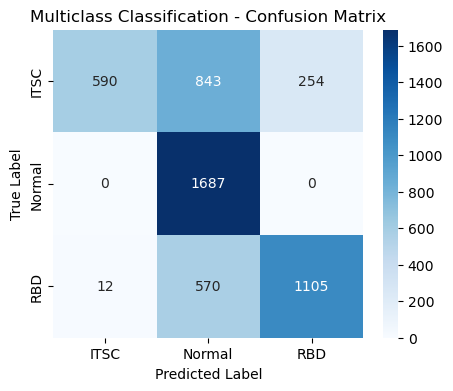

In [ ]:
fig_multi, ax_multi = plt.subplots(figsize=(5,4))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ITSC', 'Normal', 'RBD'],
            yticklabels=['ITSC', 'Normal', 'RBD'], ax=ax_multi)
ax_multi.set_xlabel('Predicted Label')
ax_multi.set_ylabel('True Label')
ax_multi.set_title('Multiclass Classification - Confusion Matrix')